<a href="https://colab.research.google.com/github/ravikeerthi7606/ImageGeneration/blob/main/ImageGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install diffusers transformers accelerate torch
!pip install safetensors

In [3]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
def refine_prompt(user_prompt):
    # Simple decision logic (you can improve later)

    if "low quality" in user_prompt:
        user_prompt = user_prompt.replace("low quality", "")

    # Add enhancements automatically
    enhanced_prompt = user_prompt + ", ultra detailed, 4k, cinematic lighting"

    return enhanced_prompt

In [5]:
from IPython.display import display

def image_agent(user_prompt):

    # Step 1: Decision (refine prompt)
    final_prompt = refine_prompt(user_prompt)
    print("Final Prompt:", final_prompt)

    # Step 2: Generate image
    image = pipe(final_prompt).images[0]

    # Step 3: Action (show + save)
    display(image)
    image.save("generated_image.png")

    print("✅ Image saved!")

Final Prompt: a futuristic city with flying cars, ultra detailed, 4k, cinematic lighting


  0%|          | 0/50 [00:00<?, ?it/s]

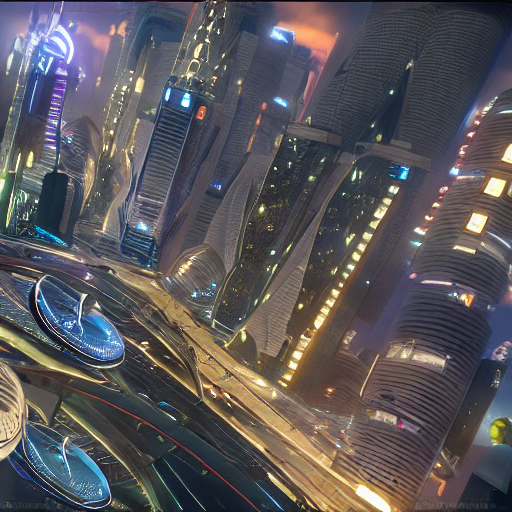

✅ Image saved!


In [6]:
image_agent("a futuristic city with flying cars")

Final Prompt: lego batman, ultra detailed, 4k, cinematic lighting


  0%|          | 0/50 [00:00<?, ?it/s]

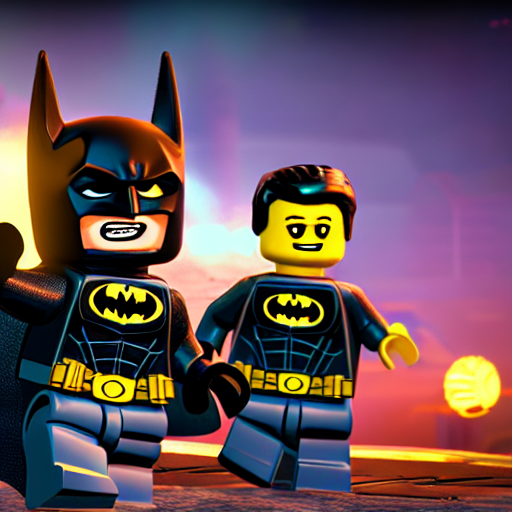

✅ Image saved!


In [7]:
image_agent("lego batman")

In [12]:
pip install --upgrade nbformat nbconvert ipywidgets

In [11]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK
